In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import StepLR

In [22]:
torch.manual_seed(42)

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [24]:
train_df = pd.read_csv('data/archive/fashion-mnist_train.csv')
test_df = pd.read_csv('data/archive/fashion-mnist_test.csv')

In [25]:
# Optional: downsample train/test for faster experiments.

In [26]:
train_df.shape, test_df.shape

((60000, 785), (10000, 785))

In [27]:
print(train_df.head())
print(train_df['label'].value_counts())
print(train_df.describe())
print(train_df.info())
print(train_df.isna().sum())

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

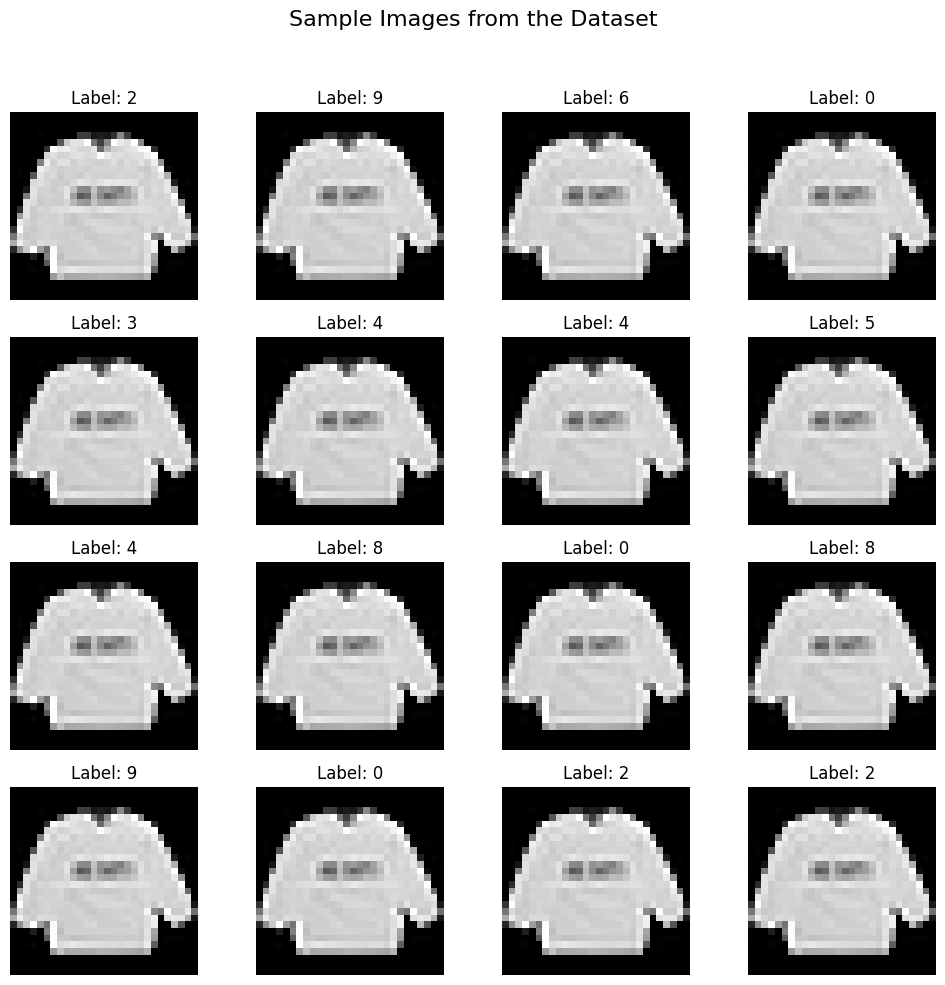

In [28]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('Sample Images from the Dataset', fontsize=16)

for i, ax in enumerate(axes.flatten()):
    image = train_df.iloc[0, 1:].values.reshape(28, 28)
    ax.imshow(image, cmap='gray')
    ax.axis('off')
    ax.set_title(f"Label: {train_df.iloc[i, 0]}")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [29]:
X_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values

In [30]:
print(X_train.shape)  # (5000, 784)
print(y_train.shape)  # (5000,)
print(X_test.shape)   # (1000, 784)
print(y_test.shape)   # (1000,)


(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [31]:
X_train = train_df.iloc[:, 1:].to_numpy(dtype="float32") / 255.0
X_test = test_df.iloc[:, 1:].to_numpy(dtype="float32") / 255.0

train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0) + 1e-7

X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

In [32]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [33]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [ ]:
class MyNN(nn.Module):
    def __init__(self, input_size, output_size, num_hidden_layers, neurons_per_layer, dropout_rate):
        super().__init__()
        layers = []

        for i in range(num_hidden_layers):
            layers.append(nn.Linear(input_size, neurons_per_layer))
            layers.append(nn.BatchNorm1d(neurons_per_layer))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            input_size = neurons_per_layer

        layers.append(nn.Linear(neurons_per_layer, output_size))

        self.model = nn.Sequential(*layers)

    def __init__weights(self, layer):
        if isinstance(layer, nn.Linear):
            nn.init.kaiming_normal_(layer.weight)
            if layer.bias is not None:
                nn.init.zeros_(layer.bias)
    
    def forward(self, x):
        return self.model(x)

In [ ]:
#objective fucntion

def objective(trial):
    #next hyperparameters values from the search space
    num_hidden_layers = trial.suggest_int('num_hidden_layers', 1, 4)
    neurons_per_layer = trial.suggest_int('neurons_per_layer', 32, 256, step=32)
    epochs = trial.suggest_int('epochs', 10, 50, step=10)
    learning_rate = trial.suggest_float('learning rate', 1e-5, 1e-1, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5, step=0.1)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'SGD', 'RMSprop'])
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)

    train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=True
    )

    #model init
    input_size = 784
    output_size = 10
    model = MyNN(input_size, output_size, num_hidden_layers, neurons_per_layer, dropout_rate).to(device)

    #optimizer selection
    criterion = nn.CrossEntropyLoss()
    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

    #training loop
    for epoch in range(epochs):
        model.train()
        for batch_features, batch_labels in train_loader:
            # Move data to the appropriate device
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

            #forward pass
            outputs = model(batch_features)

            #compute the loss
            loss = criterion(outputs, batch_labels)

            #backward pass
            optimizer.zero_grad()
            loss.backward()

            #update gradients and weights
            optimizer.step()

        scheduler.step()

    #evaluation (train only, no validation/test leakage)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_features, batch_labels in train_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = model(batch_features)
            _, predicted = torch.max(outputs.data, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()

        accuracy = 100 * correct / total

    return accuracy

In [37]:
import optuna

study = optuna.create_study(direction='maximize')

[I 2026-02-17 20:16:03,571] A new study created in memory with name: no-name-e4611a06-d781-4b52-9154-915b732fbade


In [ ]:
study.optimize(objective, n_trials=10)

In [ ]:
study.best_value

In [ ]:
study.best_params